### Input file specification :
1. File should be CSV format (can be changed from excel to CSV)
2. File name is my_file (.csv will come automatic if you save from excel)
3. Don't remove the headers
4. Remove "S. No." column if present in excel file and then change to CSV

5. Assumption : That the last column of csv is the target class
6. There is no normalization in this code.

# Code for Decision Tree

Predefined functions

In [1]:
import pandas as pd
import numpy as np

In [2]:
def entropy(prob) :
    ent = 0
    for p in prob :
        ent1 = - (p * np.log2(p))
        ent = ent + ent1
    return ent

In [3]:
def overall_entropy(test_data):
    #making dictionary of every class
    output_class = dict()
    for every_value in test_data:
        isPresent = every_value in output_class
        if(isPresent == False):
            output_class[every_value] = 1
        else:
            output_class[every_value] += 1
    print(output_class)
   
    #calculating total
    values = output_class.values()
    total = sum(values)
    print("Total number of data : ", total)
    
    #calculating entropy of each key in the dictionary
    probability_list = []
    for every_key in output_class.keys() :
        val = output_class[every_key]
        probability_list.append(val/total)
        print("\tEntropy of",every_key,"with probability", val, "/", total, "is :", entropy([val/total]))
#    print(probability_list)
    print("\033[1m\nOverall System Entropy is : ", entropy(probability_list), "\033[0m")
    return entropy(probability_list)

In [4]:
def node_classification(feature_data):
    features_dict = dict()
    classes_dict = dict()
    i=0
    for feature in feature_data:
        isPresent = feature in features_dict
        if(isPresent == False):
            features_dict[feature] = 1
            child = feature + " and " + classes[i]
            isPresent = child in classes_dict
            if(isPresent == False):
                classes_dict[child] = 1
            else :
                classes_dict[child] += 1
        else:
            features_dict[feature] += 1
            child = feature + " and " + classes[i]
            isPresent = child in classes_dict
            if(isPresent == False):
                classes_dict[child] = 1  
            else :
                classes_dict[child] += 1
        i += 1
    return features_dict,classes_dict

In [5]:
def node_impurity(features_dict,classes_dict):
    values = features_dict.values()
    total = sum(values)
    
    #calculating entropy of each key in the dictionary
    impurity_list = []
    for feature in features_dict.keys() :
        prob_list = []
        print("\n\tFor Feature", feature, "with total samples =", features_dict[feature])
        tot = features_dict[feature]
        for classes in classes_dict.keys() :
            if classes.startswith(feature) :
                val = classes_dict[classes]
                print("\t\tFor class",classes,":", val,"/",tot)
                prob_list.append(val/tot)
                print("\t\tEntropy is: ",entropy([val/total]))
        entropy_feature = entropy(prob_list)
        print("\tEntropy (sum((p*log2p) of all classes) for Feature", feature, "with probability", features_dict[feature], "/", total, "is :", entropy_feature)
        probability = features_dict[feature]/total
        impurity_list.append(entropy_feature*probability)
        print("\tImpurity (p*entropy) for Feature", feature, "with probability", features_dict[feature], "/", total, "is :", entropy_feature*probability)
    return sum(impurity_list)

In [6]:
def overall_error_rate(features_dict,classes_dict):
    print(features_dict)
    print(classes_dict, "\n")
    error_list = []
    for feature in features_dict.keys() :
        prob_list = []
        print(feature, "has", features_dict[feature], "samples")
        total = features_dict[feature]
        for classes in classes_dict.keys() :
            if classes.startswith(feature) :
                val = classes_dict[classes]
                prob_list.append(val)
        highest = max(prob_list)
        error = (total-highest)/total
        error_list.append(error)
        print("\tError of", feature, "with e(t)/n(t) i.e.", (total-highest), "/", total, "is :", error)
    return sum(error_list)
    
    

In [7]:
def node_entropy(feature_data):
    features_dict = dict()
    classes_dict = dict()
    for feature in feature_data:
        isPresent = feature in features_dict
        if(isPresent == False):
            features_dict[feature] = 1
        else:
            features_dict[feature] += 1
            
    probability_list = []
    values = features_dict.values()
    total = sum(values)
    for every_feature in features_dict.keys():
        probability = features_dict[every_feature]/total
        probability_list.append(probability)
    return entropy(probability_list)

# Main Program

In [8]:
dataset = pd.read_csv("my_file.csv", header = 0)
print(dataset)
Attributes = list(dataset.columns)
print(Attributes)
classes = dataset[Attributes[-1]]
print(classes)
classes_name = classes.unique()
print(classes_name)

  Income Married Gender Creditworthy
0      L       N      M            N
1      L       Y      F            Y
2      H       Y      F            N
3      H       N      F            N
4      H       N      M            Y
5      L       Y      F            Y
['Income', 'Married', 'Gender', 'Creditworthy']
0    N
1    Y
2    N
3    N
4    Y
5    Y
Name: Creditworthy, dtype: object
['N' 'Y']


In [9]:
impurity_of_attributes = dict()
for every_attribute in Attributes[:-1]:
    print("For attribute",every_attribute, "the classification is -->")
    input_value = dataset[every_attribute]
    features_dict,classes_dict = node_classification(input_value)
    impurity = node_impurity(features_dict,classes_dict)
    impurity_of_attributes[every_attribute] = impurity
    print("\n************************")


For attribute Income the classification is -->

	For Feature L with total samples = 3
		For class L and N : 1 / 3
		Entropy is:  0.430827083453526
		For class L and Y : 2 / 3
		Entropy is:  0.5283208335737187
	Entropy (sum((p*log2p) of all classes) for Feature L with probability 3 / 6 is : 0.9182958340544896
	Impurity (p*entropy) for Feature L with probability 3 / 6 is : 0.4591479170272448

	For Feature H with total samples = 3
		For class H and N : 2 / 3
		Entropy is:  0.5283208335737187
		For class H and Y : 1 / 3
		Entropy is:  0.430827083453526
	Entropy (sum((p*log2p) of all classes) for Feature H with probability 3 / 6 is : 0.9182958340544896
	Impurity (p*entropy) for Feature H with probability 3 / 6 is : 0.4591479170272448

************************
For attribute Married the classification is -->

	For Feature N with total samples = 3
		For class N and N : 2 / 3
		Entropy is:  0.5283208335737187
		For class N and Y : 1 / 3
		Entropy is:  0.430827083453526
	Entropy (sum((p*log2p) o

### Overall Entropy and Decrease in Impurity (Information Gain)

In [10]:
Root_node_entropy = overall_entropy(classes)

{'N': 3, 'Y': 3}
Total number of data :  6
	Entropy of N with probability 3 / 6 is : 0.5
	Entropy of Y with probability 3 / 6 is : 0.5

Overall System Entropy is :  1.0 


In [11]:
print(impurity_of_attributes)
decrease_in_impurity = dict()
n=1
for every_impurity in impurity_of_attributes.keys():
    print("\n",n, ".For attribute",every_impurity, "-->  \tImpurity (Net Entropy i.i. sum of all feature values impurity) is", impurity_of_attributes[every_impurity])
    dec_impurity = Root_node_entropy - impurity_of_attributes[every_impurity]
    print("\033[1m\t\t\t\tDecrease in Impurity is", dec_impurity, "\033[0m")
    decrease_in_impurity[every_impurity] = dec_impurity
    n +=1
    
max_dec_impurity = max(decrease_in_impurity, key=decrease_in_impurity.get)
print("\033[1m\nBest split with highest decrease in impurity is", max_dec_impurity, "\033[0m")

{'Income': 0.9182958340544896, 'Married': 0.9182958340544896, 'Gender': 1.0}

 1 .For attribute Income -->  	Impurity (Net Entropy i.i. sum of all feature values impurity) is 0.9182958340544896
				Decrease in Impurity is 0.08170416594551044 

 2 .For attribute Married -->  	Impurity (Net Entropy i.i. sum of all feature values impurity) is 0.9182958340544896
				Decrease in Impurity is 0.08170416594551044 

 3 .For attribute Gender -->  	Impurity (Net Entropy i.i. sum of all feature values impurity) is 1.0
				Decrease in Impurity is 0.0 

Best split with highest decrease in impurity is Income 


### Overall Error Rate

In [12]:
node = (dataset[max_dec_impurity])
features_dict,classes_dict = node_classification(node)
Error = overall_error_rate(features_dict,classes_dict)
print("\033[1m\nOverall error rate with Attributes", max_dec_impurity, "as parent node = ", Error, "\033[0m")

{'L': 3, 'H': 3}
{'L and N': 1, 'L and Y': 2, 'H and N': 2, 'H and Y': 1} 

L has 3 samples
	Error of L with e(t)/n(t) i.e. 1 / 3 is : 0.3333333333333333
H has 3 samples
	Error of H with e(t)/n(t) i.e. 1 / 3 is : 0.3333333333333333

Overall error rate with Attributes Income as parent node =  0.6666666666666666 


### Gain Ratio or Normalized Impurity Decrease 
Gain Ratio of an attribute is decrease in impurity of that attribute divided by entropy of that attribute(without doing dub-sivision with class)
GR(S,A) = Information_Gain( S,A)/ IntI(S,A)

In [13]:
for every_attribute in decrease_in_impurity.keys():
    input_value = dataset[every_attribute]
    node_entropy_Edt = node_entropy(input_value)
    gain_ratio = decrease_in_impurity[every_attribute]/node_entropy_Edt
    print("\033[1m\nFor attribute",every_attribute , "Gain ratio is", gain_ratio, "\033[0m")



For attribute Income Gain ratio is 0.08170416594551044 

For attribute Married Gain ratio is 0.08170416594551044 

For attribute Gender Gain ratio is 0.0 


# Decision Tree with best split

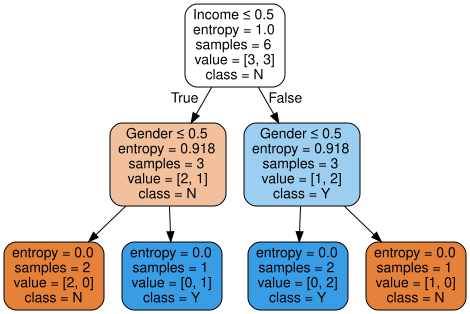

In [14]:
from sklearn import tree
from sklearn import preprocessing

#label encoding for changing string values to numerical
label_encoder = preprocessing.LabelEncoder()
for attribute in Attributes :
    dataset[attribute]= label_encoder.fit_transform(dataset[attribute])  
    
#spliting train and test data
train_data = dataset[Attributes[:-1]]
test_data = dataset[Attributes[-1]]
#print(train_data)
#print(test_data)

#train classifier

clf = tree.DecisionTreeClassifier(criterion='entropy')
clf=clf.fit(train_data,test_data)

#draw tree

import graphviz
dot_data = tree.export_graphviz(clf, 
                                out_file=None,
                                feature_names=Attributes[:-1],
                                class_names=classes_name,
                                filled=True, 
                                rounded=True,
                                special_characters=True)  
graph = graphviz.Source(dot_data)
graph